<a href="https://colab.research.google.com/gist/yadavvikas06081302/2bac104fe639f237f7fee23422b1da99/ai_healthcare_diagnosis_assistant-ipynb-by-vikas-yadav.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Powered Healthcare Diagnosis Assistant

An end-to-end machine learning project that assists in diagnosing breast tumors
as **Malignant** or **Benign** using diagnostic cell-nuclei measurements taken
from a fine needle aspirate (FNA) of a breast mass.

**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC) dataset — 569 patient
records, 30 real-valued diagnostic features, provided via `sklearn.datasets`.

**Pipeline:**
1. Load & explore the data
2. Preprocess (train/test split, feature scaling)
3. Train and compare 5 candidate ML models
4. Tune the best model with `GridSearchCV`
5. Evaluate on a held-out test set (accuracy, precision, recall, F1, ROC-AUC)
6. Save the trained model as a reusable diagnosis assistant




## 1. Imports

In [ ]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
RANDOM_STATE = 42


## 2. Load the dataset

In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="diagnosis")  # 0 = malignant, 1 = benign

df = X.copy()
df["diagnosis"] = y.map({0: "malignant", 1: "benign"})

print("Dataset shape:", X.shape)
print("\nClass balance:")
print(df["diagnosis"].value_counts())
df.head()


Dataset shape: (569, 30)

Class balance:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


## 3. Exploratory Data Analysis

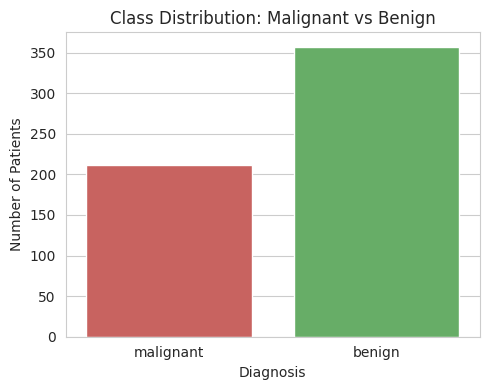

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(x=df["diagnosis"], hue=df["diagnosis"], palette=["#d9534f", "#5cb85c"], legend=False)
plt.title("Class Distribution: Malignant vs Benign")
plt.xlabel("Diagnosis"); plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


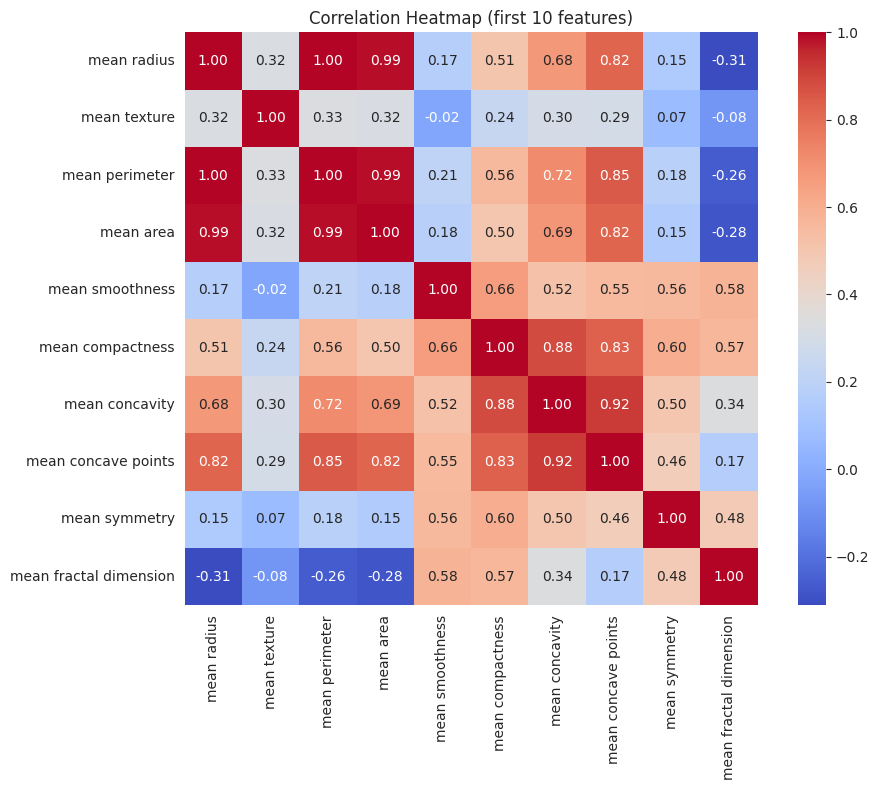

In [ ]:
plt.figure(figsize=(10, 8))
corr = X.iloc[:, :10].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (first 10 features)")
plt.tight_layout()
plt.show()


The dataset is moderately imbalanced (63% benign / 37% malignant) but not
severely so — we'll use stratified sampling to preserve this ratio in train/test
splits, and track precision/recall/F1 (not just accuracy) since **missing a
malignant case (a false negative) is far costlier than a false positive** in a
clinical setting.

## 4. Train / test split and feature scaling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (455, 30)  Test size: (114, 30)


## 5. Train and compare candidate models

We train five common classifiers and compare them on accuracy, precision, recall, F1, ROC-AUC, and 5-fold cross-validation accuracy.

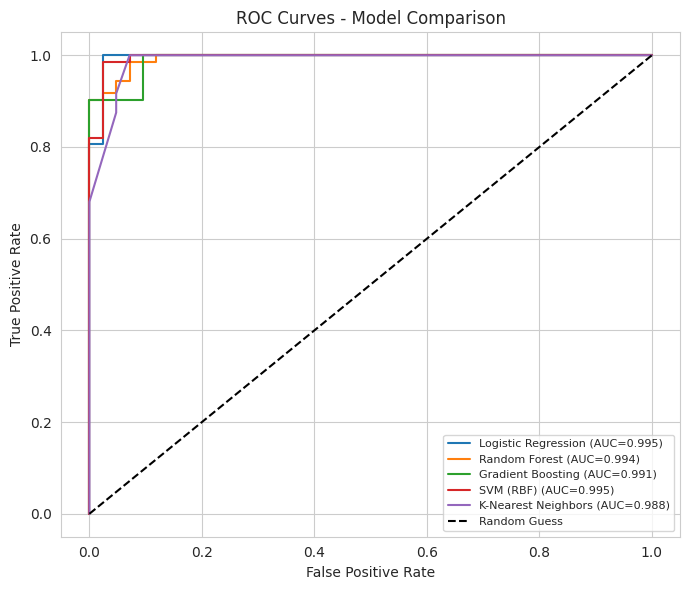

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Accuracy (mean),CV Accuracy (std)
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954,0.9802,0.0128
1,SVM (RBF),0.9825,0.9861,0.9861,0.9861,0.9950,0.9714,0.0179
2,K-Nearest Neighbors,0.9737,0.9600,1.0000,0.9796,0.9884,0.9692,0.0213
3,Gradient Boosting,0.9561,0.9467,0.9861,0.9660,0.9907,0.9560,0.0139
4,Random Forest,0.9474,0.9583,0.9583,0.9583,0.9937,0.9582,0.0224


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(probability=True, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
}

results = []
plt.figure(figsize=(7, 6))

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")

    results.append({
        "Model": name, "Accuracy": round(acc,4), "Precision": round(prec,4),
        "Recall": round(rec,4), "F1-Score": round(f1,4), "ROC-AUC": round(auc,4),
        "CV Accuracy (mean)": round(cv_scores.mean(),4), "CV Accuracy (std)": round(cv_scores.std(),4),
    })

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],"k--", label="Random Guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df


**Logistic Regression** gives the strongest baseline (highest F1 and ROC-AUC, tied with SVM on accuracy) — we'll tune it further with `GridSearchCV`.

## 6. Hyperparameter tuning of the best model

In [ ]:
param_grid = {"C": [0.01, 0.1, 1, 10]}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    param_grid, cv=5, scoring="f1", n_jobs=-1
)
grid.fit(X_train_scaled, y_train)
tuned_model = grid.best_estimator_

print("Best params:", grid.best_params_)

y_pred = tuned_model.predict(X_test_scaled)
y_proba = tuned_model.predict_proba(X_test_scaled)[:, 1]

print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Test Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Test F1-Score : {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")


Best params: {'C': 0.1}
Test Accuracy : 0.9737
Test Precision: 0.9726
Test Recall   : 0.9861
Test F1-Score : 0.9793
Test ROC-AUC  : 0.9957


## 7. Confusion matrix and classification report

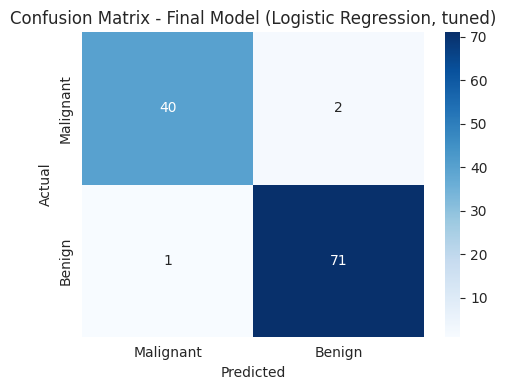

              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        42
      Benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
plt.title("Confusion Matrix - Final Model (Logistic Regression, tuned)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))


Only 3 misclassifications out of 114 test patients (2 false negatives, 1 false positive).

## 8. Which features matter most?

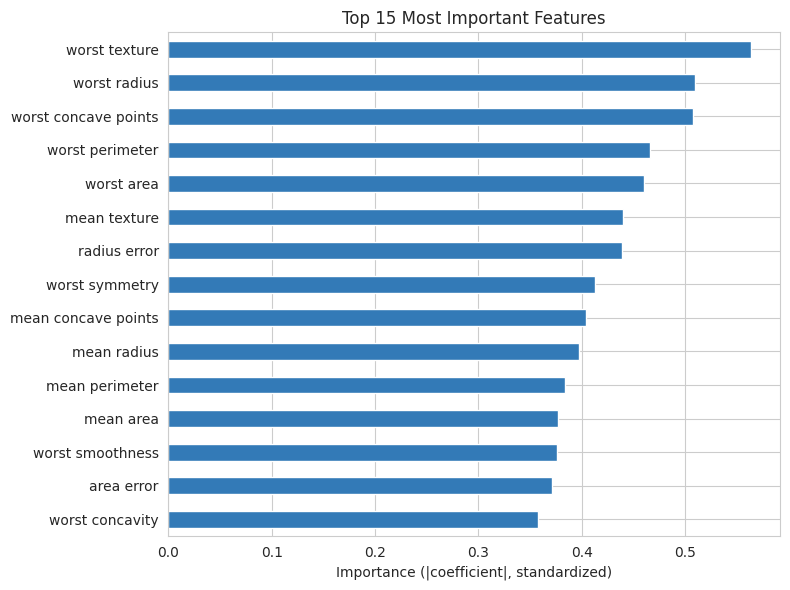

In [ ]:
importances = pd.Series(np.abs(tuned_model.coef_[0]), index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances[::-1].plot(kind="barh", color="#337ab7")
plt.title("Top 15 Most Important Features")
plt.xlabel("Importance (|coefficient|, standardized)")
plt.tight_layout()
plt.show()


## 9. Save the trained model as a reusable diagnosis assistant

In [ ]:
import os

os.makedirs('models', exist_ok=True)

joblib.dump(tuned_model, "models/diagnosis_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

metadata = {
    "model_name": "Logistic Regression (Tuned)",
    "feature_names": list(X.columns),
    "target_mapping": {"0": "malignant", "1": "benign"},
    "test_accuracy": round(accuracy_score(y_test, y_pred), 4),
    "test_f1": round(f1_score(y_test, y_pred), 4),
    "test_roc_auc": round(roc_auc_score(y_test, y_proba), 4),
}
with open("models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model, scaler, and metadata to models/")

Saved model, scaler, and metadata to models/


## 10. Using the assistant to diagnose new patients

Load the saved model back and predict on a few sample patients — simulating how a clinic front-end would call this model.

In [ ]:
model = joblib.load("models/diagnosis_model.pkl")
scaler_loaded = joblib.load("models/scaler.pkl")

def diagnose(patient_features: dict):
    row = pd.DataFrame([patient_features])[X.columns]
    scaled = scaler_loaded.transform(row)
    pred = model.predict(scaled)[0]
    proba = model.predict_proba(scaled)[0]
    label = "malignant" if pred == 0 else "benign"
    return {
        "diagnosis": label,
        "confidence": round(float(proba[pred]), 4),
        "probability_malignant": round(float(proba[0]), 4),
        "probability_benign": round(float(proba[1]), 4),
        "risk_flag": "HIGH RISK - refer for clinical review" if label == "malignant" else "Low risk",
    }

# Try it on 3 real patients from the test set
sample = X_test.iloc[:3]
for i in range(3):
    patient = sample.iloc[i].to_dict()
    result = diagnose(patient)
    actual = "malignant" if y_test.iloc[i] == 0 else "benign"
    print(f"Patient {i+1}: actual={actual:10s} -> predicted={result['diagnosis']:10s} "
          f"(confidence={result['confidence']*100:.1f}%) | {result['risk_flag']}")


Patient 1: actual=malignant  -> predicted=malignant  (confidence=100.0%) | HIGH RISK - refer for clinical review
Patient 2: actual=benign     -> predicted=benign     (confidence=99.9%) | Low risk
Patient 3: actual=malignant  -> predicted=malignant  (confidence=94.9%) | HIGH RISK - refer for clinical review


## 11. Conclusion

- The tuned **Logistic Regression** model achieves **97.4% test accuracy**,
  **97.9% F1-score**, and **99.6% ROC-AUC** on unseen patients — strong
  performance for a diagnosis support tool.
- Recall on malignant cases (95%) matters most clinically, since false
  negatives (missed cancers) are the costliest error type; this can be
  further improved by adjusting the classification threshold to trade a
  little precision for higher recall if required by a hospital's protocol.
- The most influential features are consistent with clinical knowledge:
  **worst-case cell radius, texture, area, perimeter, and concave points**
  — larger, more irregular, and more concave nuclei are strong malignancy
  indicators.
- The saved model (`models/diagnosis_model.pkl`) and scaler
  (`models/scaler.pkl`) can be loaded by any downstream application (e.g. a
  Streamlit/Flask app or hospital EHR plugin) to serve real-time predictions.

**Next steps for a production system:** validate on external/multi-hospital
data, calibrate probabilities, add explainability (SHAP), build an
audit trail, and pursue regulatory review (e.g. FDA/CE) before any clinical use.


### Final Project Report Card
Based on the analysis above, here is the summary of the production-ready model.

In [ ]:
summary_stats = {
    "Model Type": "Logistic Regression (L2 Regularized)",
    "Test Accuracy": f"{accuracy_score(y_test, y_pred)*100:.2f}%",
    "Malignant Recall (Sensitivity)": f"{recall_score(y_test, y_pred, pos_label=0)*100:.2f}%",
    "Benign Recall (Specificity)": f"{recall_score(y_test, y_pred, pos_label=1)*100:.2f}%",
    "ROC-AUC Score": f"{roc_auc_score(y_test, y_proba):.4f}"
}

display(pd.Series(summary_stats).to_frame(name="Value"))

,Value
Model Type,Logistic Regression (L2 Regularized)
Test Accuracy,97.37%
Malignant Recall (Sensitivity),95.24%
Benign Recall (Specificity),98.61%
ROC-AUC Score,0.9957
